In [63]:
import numpy as np # generic math functions
from scipy.optimize import minimize
#from scipy.special import ellipk, factorial
#from scipy.integrate import quad

import matplotlib.pyplot as plt # plotting library
#plt.rcParams["text.usetex"] = True


import time, itertools
import sys,os
os.environ['OMP_NUM_THREADS'] = '8'
os.environ['MLK_NUM_THREADS'] = '8'

from quspin.operators import hamiltonian, quantum_operator, exp_op # Hamiltonians and operators
from quspin.basis import tensor_basis, spin_basis_1d, boson_basis_1d, boson_basis_general  # Hilbert space bases
from quspin.tools.measurements import ED_state_vs_time, obs_vs_time
from quspin.tools.evolution import evolve

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D # Required for 3D projection

%matplotlib widget

In [ ]:
def H_tfi_quspin(N, J=1.0, g=0.0, PBC=False):
    """Construct the Hamiltonian for the transverse field Ising model (TFIM) using QuSpin.
    
    Args:
        N (int): Number of qubits.
        g (float): Transverse field strength.
        J (float): Interaction strength.
        PBC (bool): If True, use periodic boundary conditions; otherwise, use open boundary conditions.
    Returns:
        Hamiltonian object for the TFIM.""" 

    h_field=[[-g,i] for i in range(N)]
    if PBC:
        J_zz=[[-J, i, (i+1) % N] for i in range(N)]
    else:
        J_zz=[[-J, i, i+1] for i in range(N-1)] 
    static_spin =[["zz",J_zz],["x",h_field]]
    dynamic_spin=[]
    basis_spin = spin_basis_1d(L=N)
    
    H_spin=hamiltonian(static_spin, dynamic_spin, basis=basis_spin, dtype=np.complex64, check_herm=False, check_symm=False)
    return H_spin

In [ ]:
def get_quspin_mass_gap(N, J, g):
    """Compute the mass gap of the transverse field Ising model (TFIM) using QuSpin.
    
    Args:
        N (int): Number of qubits.
        g (float): Transverse field strength.
        J (float): Interaction strength.
    Returns:
        float: Mass gap of the TFIM."""

    H_0 = H_tfi_quspin(N, J=J, g=g)
    energy, psi_0 = H_0.eigsh(k=2, which='SA')
    mass_gap = np.abs(energy[1]-energy[0]) #energy list is unsorted, so take the absolute value

    return mass_gap

In [66]:
N_min = 2 #min number of spins
N_max = 10 #max number of spins
Ns = np.arange(N_min, N_max+1) #number of spins to iterate over
gs = np.linspace(-1.25, 1.25, 22) #values of g to iterate over


In [67]:
mass_gaps = np.zeros((len(Ns), len(gs))) #array to hold mass gaps for each value of g

for j, N in enumerate(Ns):
    for i, g in enumerate(gs):
        mass_gaps[j, i] = get_quspin_mass_gap(int(N), 1, g)

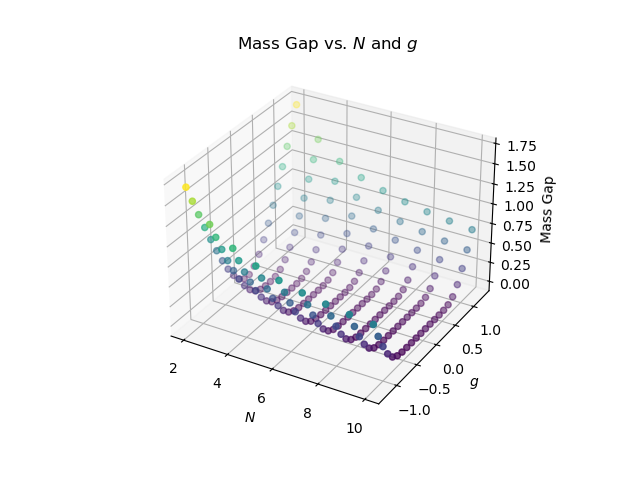

In [69]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
X, Y = np.meshgrid(Ns, gs)
ax.scatter3D(X, Y, mass_gaps.T, c=mass_gaps.T, cmap='viridis')
ax.set_xlabel('$N$')
ax.set_ylabel('$g$')
ax.set_zlabel('Mass Gap')
ax.set_title('Mass Gap vs. $N$ and $g$')
plt.show()

## Testing the classical optimizer

In [ ]:
def get_exp_U(N, thetas):
    """Construct the unitary operator exp(-i * H * t) for the transverse field Ising model (TFIM) using QuSpin.
    
    Args:
        N (int): Number of qubits.
        thetas (list): List of angles for the XX, YY, ZZ, and X terms.
    Returns:
        np.ndarray: Unitary operator exp(-i * H * t) for the TFIM"""

    basis = spin_basis_1d(N)
    XX_e = [[-thetas[0]/2, 2*n, 2*n+1] for n in range(N//2)]
    YY_e = [[-thetas[1]/2, 2*n, 2*n+1] for n in range(N//2)]
    ZZ_e = [[-thetas[2]/2, 2*n, 2*n+1] for n in range(N//2)]
    
    op_list_even = [["xx", XX_e], ["yy", YY_e], ["zz", ZZ_e]]
    operator_dict = dict(even=op_list_even)
    U_even = quantum_operator(operator_dict, basis=basis, dtype=np.complex64, check_herm=False, check_symm=False)
    exp_U_even = exp_op(U_even, a=1j)
   

    XX_o = [[-thetas[0]/2, 2*n-1, (2*n)%N] for n in range(1, N//2+1)]
    YY_o = [[-thetas[1]/2, 2*n-1, (2*n)%N] for n in range(1, N//2+1)]
    ZZ_o = [[-thetas[2]/2, 2*n-1, (2*n)%N] for n in range(1, N//2+1)]
    op_list_odd = [["xx", XX_o], ["yy", YY_o], ["zz", ZZ_o]]
    operator_dict = dict(odd=op_list_odd)
    U_odd = quantum_operator(operator_dict, basis=basis, dtype=np.complex64, check_herm=False, check_symm=False)
    exp_U_odd = exp_op(U_odd, a=1j)

    X = [[-thetas[3]/2, n] for n in range(N)]
    op_list_x = [["x", X]]
    
    operator_dict = dict(x=op_list_x)
    U_x = quantum_operator(operator_dict, basis=basis, dtype=np.complex64, check_herm=False, check_symm=False)
    exp_U_x = exp_op(U_x, a=1j)


    exp_U = exp_U_even.get_mat() @ exp_U_odd.get_mat() @ exp_U_x.get_mat()
    
    return exp_U

In [ ]:
layers = 2
thetas = np.zeros((layers,4)) # 2 layers, 4 angles each
thetas.flatten()

array([0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
def get_ansatz_unitary(N, thetas, layers):
    """Construct the ansatz unitary operator for the transverse field Ising model (TFIM) using QuSpin.
    
    Args:
        N (int): Number of qubits.
        thetas (list): List of angles for the XX, YY, ZZ, and X terms.
        layers (int): Number of layers in the ansatz.
    Returns:
        np.ndarray: Ansatz unitary operator for the TFIM."""

    U = get_exp_U(N, thetas[0]) #first layer
    for j in range(layers-1):
        U_j = get_exp_U(N, thetas[j+1])
        U = U @ U_j
    return U



## Cost function

In [ ]:
def cost_func(params, g, psi_0, layers, H):
    """Cost function for the variational quantum eigensolver (VQE) for the transverse field Ising model (TFIM).
    
    Args:
        params (list): List of parameters for the ansatz.
        g (float): Transverse field strength.
        psi_0 (np.ndarray): Initial state vector.
        layers (int): Number of repetitions of the ansatz.
        H (Hamiltonian): Hamiltonian of the system.
    Returns:
        float: Energy expectation value for the given parameters."""

    thetas = params.reshape((layers, 4))
    U = get_ansatz_unitary(N, thetas, layers)
    psi_f = U @ psi_0
    energy = np.vdot(psi_f, H.dot(psi_f)).real

    cost_history_dict[str(g)]["iters"] += 1
    cost_history_dict[str(g)]["prev_vector"] = params
    cost_history_dict[str(g)]["cost_history"].append(energy)
    print(f"g={g} Iters. done: {cost_history_dict[str(g)]['iters']} [Current cost: {energy}]", 
            end="\r",
            flush=True)

    return energy

def get_GS_energy(N, g, psi_0, layers):
    """Compute the ground state energy of the transverse field Ising model (TFIM) using a variational quantum eigensolver (VQE).

    Args:
        N (int): Number of qubits.
        g (float): Transverse field strength.
        psi_0 (np.ndarray): Initial state vector.
        layers (int): Number of repetitions of the ansatz.
    Returns:
        float: Ground state energy of the TFIM."""
    
    x0 = 0.01 * np.random.random(4*layers)   # initial parameters near zero
    H = H_tfi_quspin(N, g=g)

    
    res = minimize(cost_func, x0, args=(g, psi_0, layers, H), method='COBYLA', options={'maxiter': 5000, 'disp': True})
    energy = res.fun
    return energy

### initialize state $|\psi_0\rangle = |+\rangle^{\otimes N}$, then run optimizer

In [ ]:
N = 4
layers = N//2
gs = np.linspace(-2.5, 2.5, 11) #values of g to iterate over

psi_0 = np.zeros(2**N, dtype=np.complex64)
psi_0[0] = 1/np.sqrt(2)
psi_0[-1] = 1/np.sqrt(2) 

E_GS_qiskit = [] #List to store ground state energies for each g
params_list = [] #List to store optimal parameters for each g

#Initialize cost history dictionary
outter_keys = [str(g) for g in gs]
inner_keys = ["prev_vector", "iters", "cost_history"]

cost_history_dict = {}
for outter_key in outter_keys:
    cost_history_dict[outter_key] = {}
    cost_history_dict[outter_key]["prev_vector"] = None
    cost_history_dict[outter_key]["iters"] = 0
    cost_history_dict[outter_key]["cost_history"] = []

for g in gs:
    energy = get_GS_energy(N, g, psi_0, layers)
    E_GS_qiskit.append(energy)
    params_list.append(cost_history_dict[str(g)]["prev_vector"])

Starting optimization for g=-2.5
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 1313   Least value of F = -10.417628288269043
The corresponding X is:
[-1.40012603 -1.54864289 -0.18899237 -0.73891677 -0.17668518 -0.67704434
  0.02190329  0.01524038]


Optimization for g=-2.5 complete! Ground state energy: -10.417628288269043

Starting optimization for g=-2.0
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 1095   Least value of F = -8.539958953857422
The corresponding X is:
[-1.39658216 -1.50600293 -0.26527022 -0.6913678  -0.17622212 -0.60810475
  0.06481125 -0.01278433]


Optimization for g=-2.0 complete! Ground state energy: -8.539958953857422

Starting optimization for g=-1.5
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 1046   Least value of F = -6.757418155670166
The corresponding X is:
[-1.3273993  -1.44162822 -0.

### Reconstruct ground states

In [ ]:
psi_GS_qiskit = [] #List to store ground state wavefunctions for each g
for i, g in enumerate(gs):
    thetas_opt = params_list[i].reshape((layers, 4))
    U_opt = get_ansatz_unitary(N, thetas_opt, layers)
    psi_f_opt = U_opt @ psi_0
    psi_GS_qiskit.append(psi_f_opt)

## Direct diagonalization

In [52]:

E_GS_quspin = []
psi_GS_quspin = []

for g in gs:
    H = H_tfi_quspin(N, J=1.0, g=g, PBC=True)
    E, V = H.eigsh(k=1, which='SA')
    E_GS_quspin.append(E[0])
    psi_GS_quspin.append(V)


In [59]:
#Fractional error
E_GS_quspin = np.array(E_GS_quspin)
error = np.abs((E_GS_quspin-E_GS_qiskit)/E_GS_quspin)

#Overlap
overlap_arr = np.zeros(len(gs))

for i in range(len(gs)):
    overlap_sqrt = np.abs(np.vdot(psi_GS_quspin[i], psi_GS_qiskit[i]))
    overlap_arr[i] = overlap_sqrt**2    

<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
/var/folders/26/3g2wy1kx0k72dhg7_ycw5c5c0000gr/T/ipykernel_14567/3630591775.py:28: SyntaxWarning: invalid escape sequence '\p'
  ax3.set_ylabel('$|\\langle \psi_{VQE} | \psi_{quspin} \\rangle |^2$')


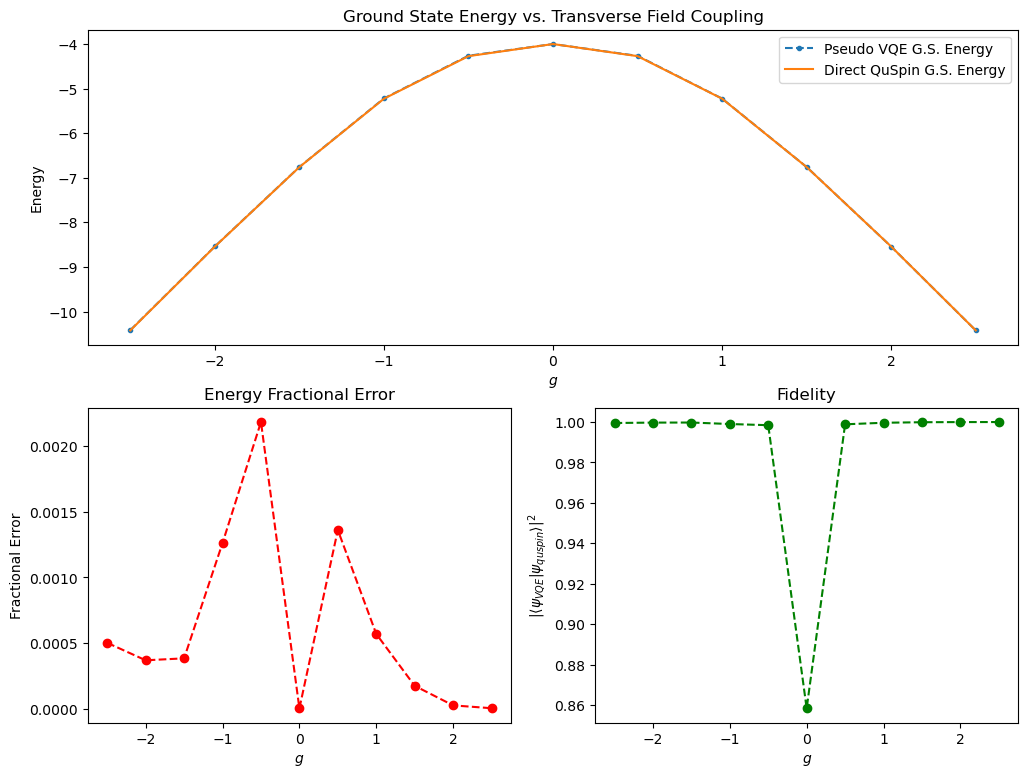

In [ ]:
layout = [['A panel', 'A panel'],
         ['B panel', 'C panel',]]
fig, axd = plt.subplot_mosaic(layout, figsize=(12, 9))
ax1 = axd['A panel']
ax1.plot(gs, E_GS_qiskit, '--.', label='Pseudo VQE G.S. Energy')
ax1.plot(gs, E_GS_quspin, label='Direct QuSpin G.S. Energy')

ax1.set_title('Ground State Energy vs. Transverse Field Coupling')
ax1.set_xlabel('$g$')
ax1.set_ylabel('Energy')
ax1.legend()

#text_str = " Parameters \n Optimizer: {} \n Entanglement: {} \n Gates: {} \n 
# Layers : {} \n N: {}".format(optimizer_name, entanglement, gates, layers, N)
#ax1.text(gs.min(), np.mean(E_gs_qiskit), text_str)

ax2 = axd['B panel']
ax2.plot(gs, error, '--o', color='red')
ax2.set_title('Energy Fractional Error')
ax2.set_xlabel('$g$')
ax2.set_ylabel('Fractional Error')

ax3 = axd['C panel']
ax3.plot(gs, overlap_arr, '--o', color='green', label="without $S$")

ax3.set_title('Fidelity')
ax3.set_xlabel('$g$')
ax3.set_ylabel(r'$|\\langle \psi_{VQE} | \psi_{quspin} \\rangle |^2$')

#fname = "TFI_VQE_plots_N={}_ansatz=symm_layers={}".format(N, N/2)

#plt.savefig(fname + '.pdf')
#ansatz.draw('mpl').savefig(circuit_fname + '.pdf')


plt.show()

In [62]:
error

array([5.01959849e-04, 3.69162980e-04, 3.84008298e-04, 1.26155847e-03,
       2.18249332e-03, 2.98023188e-06, 1.36088929e-03, 5.69603744e-04,
       1.74792989e-04, 2.60099885e-05, 4.39192194e-06])